Project 3 Jupyter Notebook
========

### Group: Engel
Authors: Ivan Chan, Kira Obsitnik, Edward Shen, Sage Tulabing, Yuheng Wang, Yixiao Yang


In this notebook, we will estimate a Constant Frisch Elasticity (CFE) demand system and discuss the landscape of the nutritional diet and its adequacy using a set of procedures discussed in the previous lecture. 

This project will use the household food expenditure data in 2019 from **Senegal**, and the Food Nutritional Table (FCT) Spreadsheet that we constructed based on the information provided in the FAO/INFOODS Food Composition Table for Western Africa (WAFCT) 2019 and the USDA FDC Database.

### Set up & Imports
Below are all necessary imports and pip installs for the rest of this project. 

**Please ensure all neccessary files are in the folder before running the below pip install.**

In [1]:
%pip install -r requirements-estimation.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from ligonlibrary.sheets import read_sheets
import matplotlib.pyplot as plt
from cfe import Regression
import cfe

## Population & Data, <span style="color: red;">*Deliverable [A] Choice of population, with supporting expenditure data* <a name="population-f"></span></a>

We decided to focus on Senegal and the effects that household gender ratios have on food expenditures and nutritional adequacy.  We were able to find a study on men’s daily intake; however, most of these men came from households where women did the cooking.  So, we are going to explore how gender might influence food demand and expenditures for the various main food groups.

The data is stored in a Google Spreadsheet: [https://docs.google.com/spreadsheets/d/1EpdHRbr4QCk_R_uD3kYjo9ZfxOdrX2sFXBsA7xD6vXo/](https://docs.google.com/spreadsheets/d/1EpdHRbr4QCk_R_uD3kYjo9ZfxOdrX2sFXBsA7xD6vXo/). It is also available in a local Excel file `Senegal Data.xlsx`.

We will use the following sheets:
* `Household Characteristics` - One row per household, with demographic columns(household members by characteristics, age/sex group, and log household size).
* `Food Expenditures (2019)` - Records of household food expenditures
* `FCT` - Food Nutrition Table, which stores the nutritional information for every unique food item that appeared in the `Food Expenditures` sheet.
* `RDI` - Recommended Dietary Intake, which stores the Recommended Dietary Intake for age/sex group.
and more...

The first two sheets share the index columns `i` (household ID), `t` (survey wave), and `m` (market/region).

In [7]:
Senegal_Data = '1EpdHRbr4QCk_R_uD3kYjo9ZfxOdrX2sFXBsA7xD6vXo'

**To avoid memory issue in Datahub, we only used urban regions for the remaining analysis.**

In [22]:
x = read_sheets(Senegal_Data,sheet='Food Expenditures (2019)')

d = read_sheets(Senegal_Data,sheet="Household Characteristics")
d.columns.name = 'k'

# Data comes in long format; pivot to wide (one column per food)
x = x.pivot_table(index=['i','t','m'],columns='j',values='Expenditure',
                   aggfunc='sum')
x = x.replace(0,np.nan) # Replace zeros with missing

# Take logs of expenditures; call this y
y = np.log(x)

d.set_index(['i','t','m'],inplace=True)

# NaN in demographic columns means zero people in that category
d = d.fillna(0)
d = d.loc[(slice(None), 2019, ['dakar', 'diourbel', 'SAINT-LOUIS', 'thies']), :]

y = y.loc[(slice(None), 2019, ['dakar', 'diourbel', 'SAINT-LOUIS', 'thies']), :]

### Household characteristics dataframe (d)
Missing values in demographic columns are treated as zero (no members of that age/sex group).

In [23]:
print(f"d shape: {d.shape}")
d.head()

d shape: (1296, 19)


,,k,women,girls,boys,men,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51+,Females 51+,log HSize
i,t,m,,,,,,,,,,,,,,,,,,,
2101,2019,dakar,5,2,3,7,0,0,0,2,2,0,1,0,3,2,3,3,1,0,2.833213
21010,2019,dakar,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0.000000
21011,2019,dakar,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0.693147
21012,2019,dakar,3,0,1,1,0,0,0,0,1,0,0,1,1,1,0,1,0,0,1.609438
2102,2019,dakar,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0.000000


### Log-expenditure dataframe (y)

In [24]:
print(f"y shape (households × foods): {y.shape}")
y.head()

y shape (households × foods): (1305, 134)


,,j,"Abats et tripes (foie, rognon, etc.)",Ail,Ananas,Arachide grillée,Arachides décortiquées ou pilées (noflaye),Arachides fraîches en coques,Arachides séchées en coques,"Arôme (Maggi, Jumbo, etc.)",Attiéke,"Aubergine, Courge/Courgette",...,Thé,Tomate fraîche,Tomate séchée,Viande d'autres volailles domestiques,Viande de b__uf,Viande de chèvre,Viande de mouton,Viande de porc,Viande de poulet,Vinaigre /moutarde
i,t,m,,,,,,,,,,,,,,,,,,,,,
221,2019,dakar,7.600902,4.605170,NaN,NaN,6.214608,NaN,NaN,NaN,NaN,4.605170,...,4.60517,6.214608,NaN,NaN,8.006368,NaN,8.160518,NaN,7.824046,6.214608
222,2019,dakar,NaN,5.298317,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.605170,...,NaN,4.605170,NaN,NaN,7.313220,NaN,NaN,NaN,NaN,NaN
223,2019,dakar,NaN,3.912023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.912023,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
224,2019,dakar,6.620073,4.605170,NaN,NaN,NaN,NaN,7.495542,NaN,NaN,NaN,...,NaN,5.298317,NaN,NaN,8.006368,NaN,8.160518,NaN,7.824046,NaN
225,2019,dakar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Estimation

**The following description is adapated from the lecture.**

Let $y_{i}^j$ be log expenditures on food $j$ by household $i$ at a particular time.  We want to estimate a regression that takes the form
$$
      y^j_{i} = A^j(p) + \gamma_j'd_i + \beta_j w_i + \zeta^j_i.
$$
So, a first step is to turn our dataframe for `y` into a series, so we can put it on the left-hand side of this regression.  Then we need to make our dataframe $d$ conform:



In [25]:
y = y.stack().dropna()

d = d.stack().dropna()

# Check that indices are in right places!
assert y.index.names == ['i','t','m','j']
assert d.index.names == ['i','t','m','k']

To set up and run the regression:

In [26]:
from cfe import Regression

result = Regression(y=y,d=d)

In [27]:
result.predicted_expenditures()

i       t     m      j                                                                  
221     2019  dakar  Ail                                                                     156.485886
                     Aubergine, Courge/Courgette                                             125.075491
                     Autre légumes frais n.d.a (y compris les fleurs blanches de bissap)     119.639786
                     Autres condiments (poivre etc.)                                         130.309385
                     Autres fruits (pommes, raisin, etc.)                                    683.916316
                                                                                               ...     
234212  2019  thies  Thé                                                                     136.192935
                     Tomate fraîche                                                           90.636907
                     Viande de b__uf                                           

Now we can compare predicted log expenditures with actual:

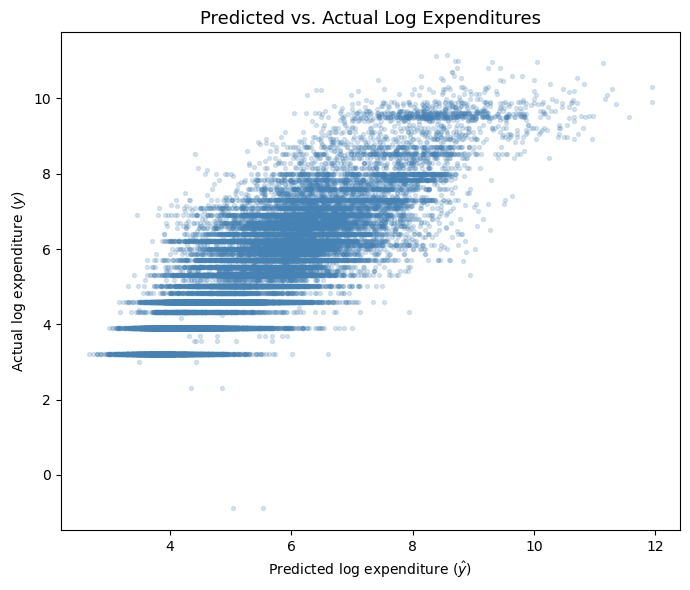

In [36]:
%matplotlib inline

df_fit = pd.DataFrame({
    'y'   : y,
    'yhat': result.get_predicted_log_expenditures()
})

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df_fit['yhat'], df_fit['y'], alpha=0.2, s=8, color='steelblue')

ax.set_xlabel('Predicted log expenditure ($\\hat{y}$)')
ax.set_ylabel('Actual log expenditure ($y$)')
ax.set_title('Predicted vs. Actual Log Expenditures', fontsize=13)
plt.tight_layout()
plt.show()

## Demand System, <span style="color: red;">*Deliverable [A] Estimate Demand System* <a name="population-f"></span></a>

Now that we have completed the estimation above, we can then proceed to develop a Demand System.

### Frisch elasticities
Some of the parameters have an interesting interpretation.  First among these are the $\beta$ coefficients, which govern how *income elastic* different goods are (higher values means more elastic).  These are also called *Frisch elasticities*.


In [37]:
result.get_beta().sort_values()

j
Salade (laitue, batavia, etc.)                                         0.267759
Mil                                                                    0.286609
Haricot vert                                                           0.395984
Pain moderne                                                           0.582432
Viande de poulet                                                       0.669070
Poisson frais yaboy ou obo (sardinelle)                                0.694920
Autres tisanes et infusions n.d.a. (quinquelibat, citronelle, etc.)    0.707190
Lait concentré non-sucré                                               0.707989
Pâte d'arachide                                                        0.727790
Concombre                                                              0.752863
Pâtes alimentaires                                                     0.772769
Thé                                                                    0.836596
Feuilles d'oseille (bissap)           

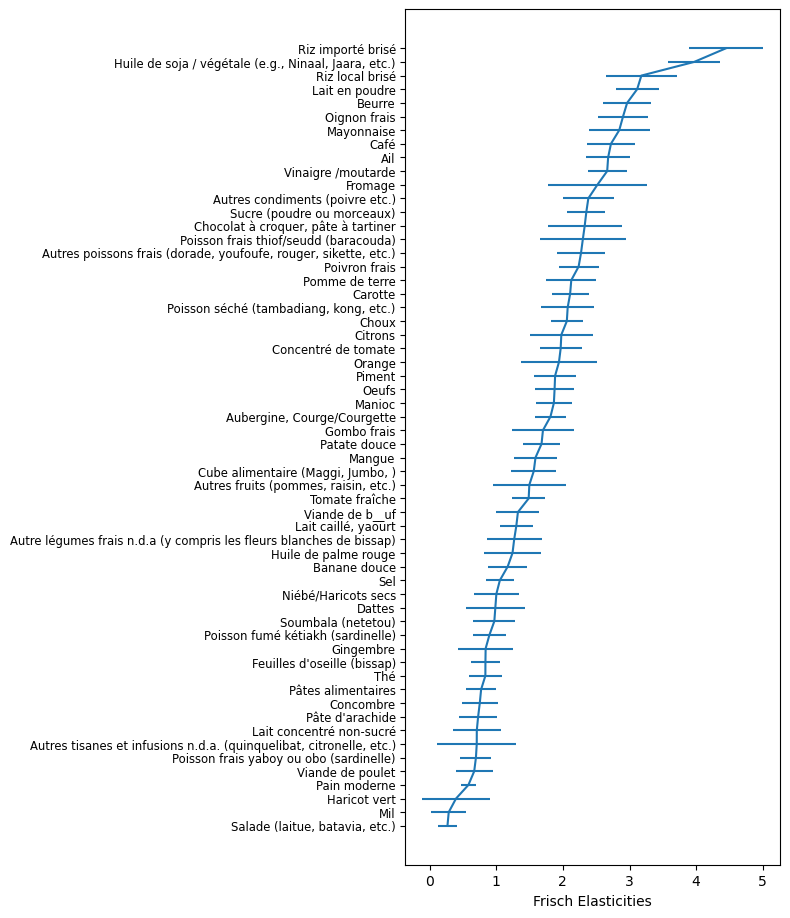

In [38]:
result.graph_beta()
plt.show()

### Household composition effects
These numbers summarize how household demographic composition shifts demand for each food, based on total expenditure. Each row is a food; each column is a demographic characteristic.

These are captured by the $\gamma_j$ parameters in the regression.

In [39]:
result.gamma

k,women,girls,boys,men,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51+,Females 51+,log HSize,Constant
j,,,,,,,,,,,,,,,,,,,,
Ail,-0.394082,-0.541954,-0.037133,0.006274,-0.115093,0.469727,0.054954,0.470392,-0.044518,0.525489,-0.010925,0.428479,0.028520,0.457370,0.027420,0.463928,0.028784,0.428378,0.072965,4.348706
"Aubergine, Courge/Courgette",0.321125,0.369397,-0.031768,0.063611,-0.019736,-0.385491,0.075380,-0.369489,0.025632,-0.358525,0.008266,-0.428471,-0.061444,-0.275419,-0.021433,-0.257392,0.025178,-0.276173,0.080532,4.429265
Autre légumes frais n.d.a (y compris les fleurs blanches de bissap),0.230888,0.278732,-0.097406,0.171065,0.111702,-0.275480,0.015058,-0.319682,0.132552,-0.120468,0.010928,-0.248723,-0.167219,-0.216765,-0.055459,-0.272201,0.026098,-0.340080,-0.140713,4.427440
Autres condiments (poivre etc.),1.450606,1.487007,-0.078289,0.051023,0.014606,-1.546956,0.097692,-1.586968,0.016887,-1.519723,0.048573,-1.586506,-0.107312,-1.362421,-0.058311,-1.325194,-0.039399,-1.323594,0.140163,4.226953
"Autres fruits (pommes, raisin, etc.)",-0.050386,-0.006718,-0.055682,-0.019919,-0.091743,0.085295,-0.130386,-0.111888,0.042859,-0.028806,-0.105794,-0.077514,-0.049442,0.014493,0.076359,0.016708,0.182548,0.060004,0.351343,6.173731
"Autres poissons frais (dorade, youfoufe, rouger, sikette, etc.)",-0.656305,-0.583909,-0.101841,0.112881,0.018591,0.608334,0.027403,0.480617,0.193015,0.604860,0.037100,0.542972,-0.129994,0.685998,-0.081047,0.744805,-0.054027,0.934991,-0.074870,6.933776
"Autres tisanes et infusions n.d.a. (quinquelibat, citronelle, etc.)",-0.079401,0.059409,-0.006080,0.062320,0.054793,-0.169869,-0.110330,-0.082454,0.027746,0.040340,-0.117884,-0.071373,-0.006501,0.149097,-0.127525,0.046158,0.335940,0.079900,-0.129520,4.728263
Banane douce,-0.050377,0.019296,-0.074193,0.045619,-0.031389,0.046969,0.050563,-0.059602,0.193964,-0.094404,-0.077696,-0.012490,-0.156458,0.034893,-0.130237,0.032740,0.122678,0.036174,0.321563,6.160526
Beurre,-1.030546,-1.256958,-0.095085,0.112615,0.019103,1.124805,0.269482,1.396317,0.093400,1.269564,0.017857,1.109358,-0.121638,1.171073,-0.167194,1.057789,-0.093480,1.173874,-0.135980,5.501278
